Adapted from the exact kinetic energy operator script used by Mellor et al. 2022 for H2CS. The approach taken here is slightly different in that we do not use Sorensen's procedure with the axial constraints and instead opt for t-matrix inversion, using a reduced Cartesian system of valence vectors as an intermediate.

In [ ]:
(* Changes precision. Change value from default 12*)
$PreRead = (# /. 
     s_String /; 
       StringMatchQ[s, NumberString] && 
        Precision@ToExpression@s == MachinePrecision :> 
      s <> "`34." &);

In [4]:
(* Simplifies the expression solely using Pythagoras' theorem*)
SCSimplify[expr_] := 
 Simplify[expr, Trig -> False, 
  TransformationFunctions -> {Automatic, (# /. 
       Sin[a_]^2 + Cos[a_]^2 :> 1) &}]

Here we invert the relations between primitive internal dihedrals and symmeterised dihedrals to find the primitive dihedrals as a function of the symmeterised coordinates. In the current setting the ordering of hydrogens is d1 < d3 < d2.

d
 12

d
 13

d
 23


τ
    d          d
     12         13          2
-(-------) - ------- + Sqrt[-] d
  Sqrt[6]    Sqrt[6]        3   23

    d          d
     12         13
-(-------) + -------
  Sqrt[2]    Sqrt[2]



d   + d   + d
 12    13    23
     1            1            2
-(-------)   -(-------)   Sqrt[-]
  Sqrt[6]      Sqrt[6]         3

     1          1
-(-------)   -------
  Sqrt[2]    Sqrt[2]      0



1            1            1
S
 a

S
 b


2 Pi
                S         S
       2 Pi      a         b
d   -> ---- - ------- - -------
 12     3     Sqrt[6]   Sqrt[2]

                S         S
       2 Pi      a         b
d   -> ---- - ------- + -------
 13     3     Sqrt[6]   Sqrt[2]


       2 Pi        2
d   -> ---- + Sqrt[-] S
 23     3          3   a
         S         S
2 Pi      a         b
---- - ------- - -------
 3     Sqrt[6]   Sqrt[2]

         S         S
2 Pi      a         b
---- - ------- + -------
 3     Sqrt[6]   Sqrt[2]


2 Pi        2
---- + Sqrt[-] S
 3          3   a


2 Pi + d  - d
        1    2



-d  + d
  1    3



d  - d
 2    3

        d    d    d
-2 Pi    1    2    3
----- + -- + -- + --
  3     3    3    3
1        1
-      -(-)
3        3    0      1

1      2
-      -
3      3      1      1

1      2
-      -
3      3      0      1



1      1      1      0
    Sqrt[2] S
             b
τ - ----------
        3

             S          S
4 Pi          a          b
---- + τ + ------- + ---------
 3         Sqrt[6]   3 Sqrt[2]

             S          S
2 Pi          a          b
---- + τ - ------- + ---------
 3         Sqrt[6]   3 Sqrt[2]




2 Pi
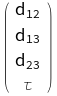
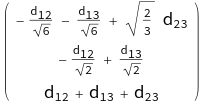
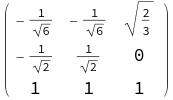
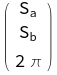
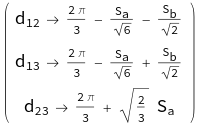
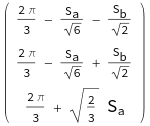
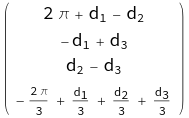
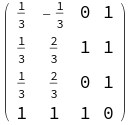
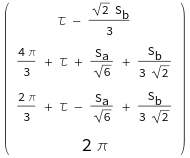

In [9]:
dihedralDifferences = {Subscript[d, 12], Subscript[d, 13], Subscript[d, 23], \[Tau]};
MatrixForm[dihedralDifferences]
dihedralsToSymmeterised = {1/Sqrt[6] {-1, -1, 2}, 1/Sqrt[2] {-1, 1, 0}, {1, 1, 1}};
MatrixForm[dihedralsToSymmeterised . dihedralDifferences[[;;3]]]
MatrixForm[dihedralsToSymmeterised]
symmeterisedDihedrals = {Subscript[S, a], Subscript[S, b], 2Pi};
MatrixForm[symmeterisedDihedrals]
symmeterisedToDihedrals = Inverse[dihedralsToSymmeterised];
dihedralDifferenecesAsSymmeterised = symmeterisedToDihedrals . symmeterisedDihedrals;
replaceDifferencesWithDihedrals = Thread[dihedralDifferences[[1 ;; 3]] -> dihedralDifferenecesAsSymmeterised];
MatrixForm[replaceDifferencesWithDihedrals]
MatrixForm[dihedralDifferenecesAsSymmeterised]
(* dihedralsToDifferences = {{-1, 1, 0, 0}, {1, 0, -1, 1}, {0, -1, 1, 0}, 1/3{1, 1, 1, -1}}; *)
(* Swap dihedrals *)
dihedralsToDifferences = {{1, -1, 0, 1}, {-1, 0, 1, 0}, {0, 1, -1, 0}, 1/3 {1, 1, 1, -1}};
dihedrals = {Subscript[d, 1], Subscript[d, 2], Subscript[d, 3], 2Pi};
MatrixForm[dihedralsToDifferences . dihedrals]
differencesToDihedrals = Inverse[dihedralsToDifferences];
MatrixForm[differencesToDihedrals]
dihedralsAsDifferences = (differencesToDihedrals . dihedralDifferences /. replaceDifferencesWithDihedrals) // FullSimplify // Expand;
MatrixForm[dihedralsAsDifferences] 

1              0              0              0              0
 


>    0              0              0              0              0
 


>    0



0              1              0              0              0
 


>    0              0              0              0              0
 


>    0



0              0              0              0              1
 


>    0              0              0              0              0
 


>    0



0              0              0              1              0
 


>    0              0              0              0              0
 


>    0



0              0              1              0              0
 


>    0              0              0              0              0
 


>    0



0              0              0              0              0
 


>    1              0              0              0              0
 


>    0



0              0              0              0              0
 


>    0              0              0              1              0
 


>    0



0              0              0              0              0
 


>    0              0              1              0              0
 


>    0



0              0              0              0              0
 


>    0              1              0              0              0
 


>    0



0              0              0              0              0
 
                                                                   1
                                                                 -(-)
>    0              0              0              0                2
 
       1
     -(-) Sqrt[3]
>      2



0              0              0              0              0
 
                                                                   1
                                                                 -(-) Sqrt[3]
>    0              0              0              0                2
 
     1
     -
>    2


1              0              0              0              0
 


>    0              0              0              0              0
 


>    0



0              1              0              0              0
 


>    0              0              0              0              0
 


>    0



0              0              0              0              1
 


>    0              0              0              0              0
 


>    0



0              0              1              0              0
 


>    0              0              0              0              0
 


>    0



0              0              0              1              0
 


>    0              0              0              0              0
 


>    0



0              0              0              0              0
 


>    1              0              0              0              0
 


>    0



0              0              0              0              0
 


>    0              0              0              1              0
 


>    0



0              0              0              0              0
 


>    0              1              0              0              0
 


>    0



0              0              0              0              0
 


>    0              0              1              0              0
 


>    0



0              0              0              0              0
 
                                                                   1
                                                                 -(-)
>    0              0              0              0                2
 
       1
     -(-) Sqrt[3]
>      2



0              0              0              0              0
 
                                                                 Sqrt[3]
                                                                 -------
>    0              0              0              0                 2
 
       1
     -(-)
>      2

r
 CO


r
 OH

r
 CH
   1

r
 CH
   2

r
 CH
   3


α
 HOC

α
 HCO
    1

α
 HCO
    2

α
 HCO
    3


S
 a


S

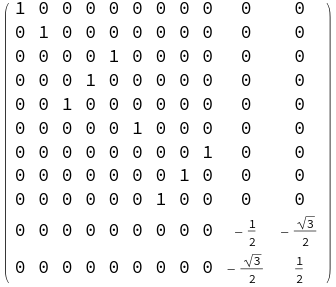
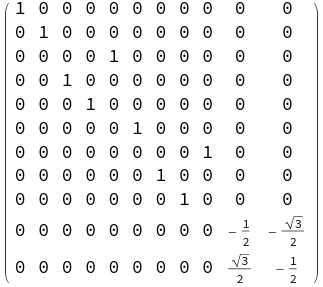
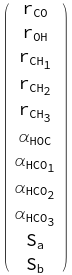
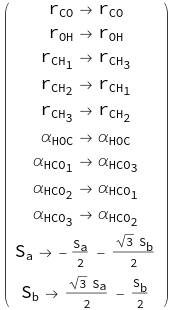
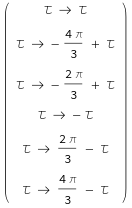
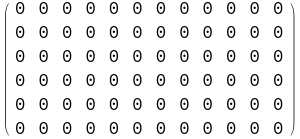
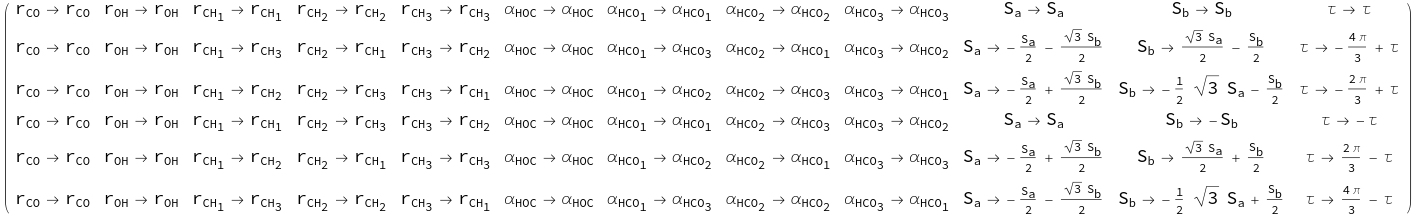

In [44]:
valenceCoordinates = {Subscript[r, CO], Subscript[r, OH], Subscript[r, Subscript[CH, 1]], Subscript[r, Subscript[CH, 2]], Subscript[r, Subscript[CH, 3]],
Subscript[\[Alpha], HOC], Subscript[\[Alpha], Subscript[HCO, 1]], Subscript[\[Alpha], Subscript[HCO, 2]], Subscript[\[Alpha], Subscript[HCO, 3]], Subscript[S, a], Subscript[S, b], \[Tau]};
numberOfSymmetryOperations = 6;
numberOfModes=12;
symmetryOperations = ConstantArray[0, {numberOfSymmetryOperations, 11, 11}];
symmetryOperations[[1, ;;, ;;]] = IdentityMatrix[11];
(* 123 *)
symmetryOperations[[2, ;;, ;;]] = {
	{1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0},
	{0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0},
	{0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0},
	{0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0},
	{0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0},
	{0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0},
	{0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0},
	{0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0},
	{0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0},
	{0, 0, 0, 0, 0, 0, 0, 0, 0, -(1/2), -(Sqrt[3]/2)},
	{0, 0, 0, 0, 0, 0, 0, 0, 0, Sqrt[3]/2, -(1/2)}
};
(* 132 *)
symmetryOperations[[3, ;;, ;;]] = Transpose[symmetryOperations[[2, ;;, ;;]]];
(* 23 *)
symmetryOperations[[4, ;;, ;;]] = {
	{1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0},
	{0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0},
	{0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0},
	{0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0},
	{0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0},
	{0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0},
	{0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0},
	{0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0},
	{0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0},
	{0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0},
	{0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1}
};
(* 12 *)
symmetryOperations[[5, ;;, ;;]] = {
	{1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0},
	{0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0},
	{0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0},
	{0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0},
	{0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0},
	{0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0},
	{0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0},
	{0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0},
	{0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0},
	{0, 0, 0, 0, 0, 0, 0, 0, 0, -(1/2), Sqrt[3]/2},
	{0, 0, 0, 0, 0, 0, 0, 0, 0, Sqrt[3]/2, 1/2}
};
(* 13 *)
symmetryOperations[[6, ;;, ;;]] = {
	{1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0},
	{0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0},
	{0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0},
	{0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0},
	{0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0},
	{0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0},
	{0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0},
	{0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0},
	{0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0},
	{0, 0, 0, 0, 0, 0, 0, 0, 0, -(1/2), -(Sqrt[3]/2)},
	{0, 0, 0, 0, 0, 0, 0, 0, 0, -(Sqrt[3]/2), 1/2}
};
MatrixForm[symmetryOperations[[6, ;;, ;;]]]
(* dihedral differences *)
torsionSymmetryOperations = {
	\[Tau] -> \[Tau],          (* E *)
	\[Tau] -> \[Tau] - 4Pi/3,  (* 123 *)
	\[Tau] -> \[Tau] - 2Pi/3,  (* 132 *)
	\[Tau] -> -\[Tau],         (* 23 *)
	\[Tau] -> -\[Tau] + 2Pi/3, (* 12 *)
	\[Tau] -> -\[Tau] + 4Pi/3  (* 13 *)
}; 
MatrixForm[symmetryOperations[[2, ;;, ;;]]]
MatrixForm[valenceCoordinates[[;; 11]]]
MatrixForm[Thread[valenceCoordinates[[;; 11]] -> symmetryOperations[[2, ;;, ;;]] . valenceCoordinates[[;; 11]]]]
MatrixForm[torsionSymmetryOperations]
valenceSymmetrySubsitutionRules = ConstantArray[ConstantArray[0, numberOfModes], numberOfSymmetryOperations];
MatrixForm[valenceSymmetrySubsitutionRules]
For[i = 1, i <= numberOfSymmetryOperations, i++,
	valenceSymmetrySubsitutionRules[[i]][[;; numberOfModes - 1]] = Thread[valenceCoordinates[[;; numberOfModes - 1]] -> symmetryOperations[[i, ;;, ;;]] . valenceCoordinates[[;; numberOfModes - 1]]];
	valenceSymmetrySubsitutionRules[[i]][[numberOfModes]] = torsionSymmetryOperations[[i]];
];
MatrixForm[valenceSymmetrySubsitutionRules]

m
 C

m
 O

m
 H

m
 H

m
 H

m
 H

x     y     z
 C     C     C


x     y     z
 O     O     O


x     y     z
 H     H     H

x     y     z
 H     H     H
  1     1     1

x     y     z
 H     H     H
  2     2     2

x     y     z
 H     H     H
  3     3     3
m  x  + m  x  + m  x  + m  x   + m  x   + m  x
 C  C    H  H    O  O    H  H     H  H     H  H
                             1        2        3
------------------------------------------------
                 m  + 4 m  + m
                  C      H    O

m  y  + m  y  + m  y  + m  y   + m  y   + m  y
 C  C    H  H    O  O    H  H     H  H     H  H
                             1        2        3
------------------------------------------------
                 m  + 4 m  + m
                  C      H    O

m  z  + m  z  + m  z  + m  z   + m  z   + m  z
 C  C    H  H    O  O    H  H     H  H     H  H
                             1        2        3
------------------------------------------------
                 m  + 4 m  + m
                  C      H    O
     m  x  + m  x  + m  (x  + x   + x   + x  )
      C  C    O  O    H   H    H     H     H
                                1     2     3
x  - -----------------------------------------
 C                m  + 4 m  + m
                   C      H    O
 
          m  y  + m  y  + m  (y  + y   + y   + y  )
           C  C    O  O    H   H    H     H     H
                                     1     2     3
     y  - -----------------------------------------
      C                m  + 4 m  + m
>                       C      H    O
 
          m  z  + m  z  + m  (z  + z   + z   + z  )
           C  C    O  O    H   H    H     H     H
                                     1     2     3
     z  - -----------------------------------------
      C                m  + 4 m  + m
>                       C      H    O

m  (-x  + x ) - m  (x  - 4 x  + x   + x   + x  )
 C    C    O     H   H      O    H     H     H
                                  1     2     3
------------------------------------------------
                 m  + 4 m  + m
                  C      H    O
 
     m  (-y  + y ) - m  (y  - 4 y  + y   + y   + y  )
      C    C    O     H   H      O    H     H     H
                                       1     2     3
     ------------------------------------------------
                      m  + 4 m  + m
>                      C      H    O
 
     m  (-z  + z ) - m  (z  - 4 z  + z   + z   + z  )
      C    C    O     H   H      O    H     H     H
                                       1     2     3
     ------------------------------------------------
                      m  + 4 m  + m
>                      C      H    O

     m  x  + m  x  + m  (x  + x   + x   + x  )
      C  C    O  O    H   H    H     H     H
                                1     2     3
x  - -----------------------------------------
 H                m  + 4 m  + m
                   C      H    O
 
          m  y  + m  y  + m  (y  + y   + y   + y  )
           C  C    O  O    H   H    H     H     H
                                     1     2     3
     y  - -----------------------------------------
      H                m  + 4 m  + m
>                       C      H    O
 
          m  z  + m  z  + m  (z  + z   + z   + z  )
           C  C    O  O    H   H    H     H     H
                                     1     2     3
     z  - -----------------------------------------
      H                m  + 4 m  + m
>                       C      H    O

      m  x  + m  x  + m  (x  + x   + x   + x  )
       C  C    O  O    H   H    H     H     H
                                 1     2     3
x   - -----------------------------------------
 H                 m  + 4 m  + m
  1                 C      H    O
 
           m  y  + m  y  + m  (y  + y   + y   + y  )
            C  C    O  O    H   H    H     H     H
                                      1     2     3
     y   - -----------------------------------------
      H                 m  + 4 m  +
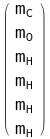
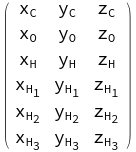
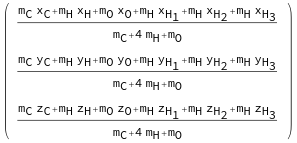
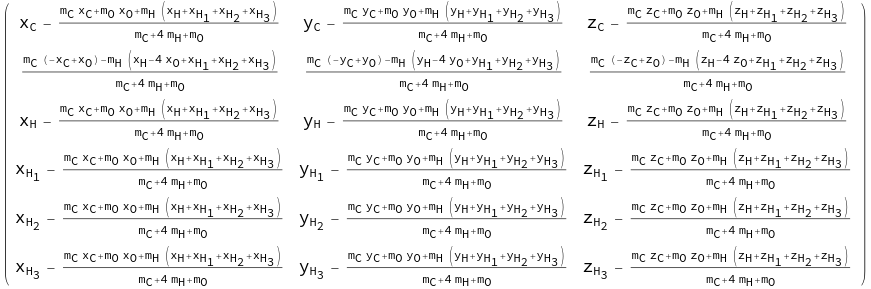
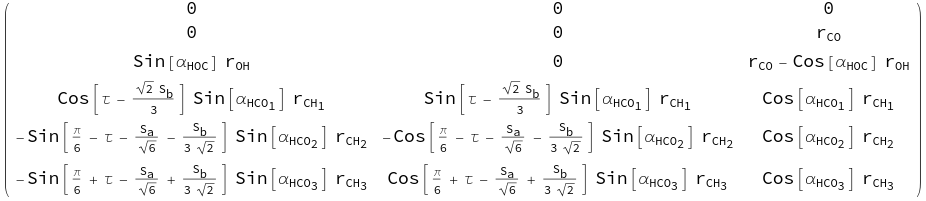
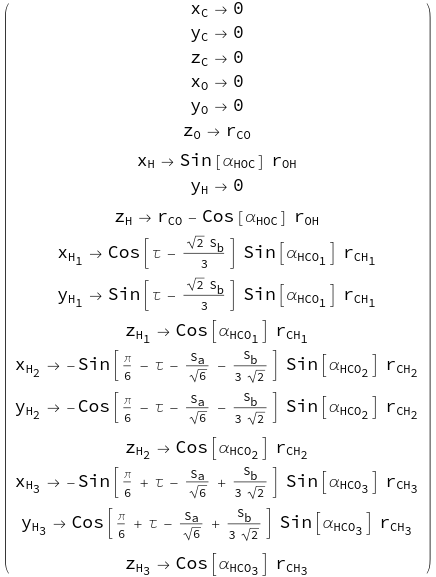
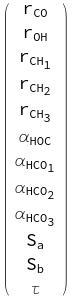
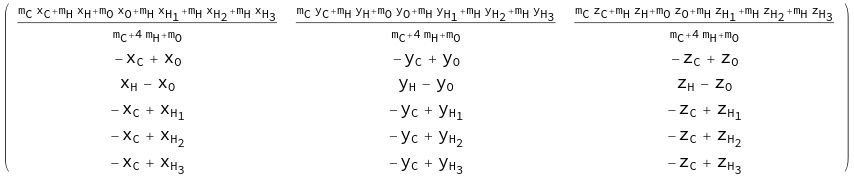

In [69]:
convertToRadians = 2*Pi/360;
numberOfAtoms = 6;
numberOfModes = 12;
masses = {Subscript[m, C], Subscript[m, O], Subscript[m, H], Subscript[m, H], Subscript[m, H], Subscript[m, H]};
MatrixForm[masses]
massSubstitution = {Subscript[m, C] -> 12.00000000`34, Subscript[m, O] -> 15.99491463`34, Subscript[m, H] -> 1.00782505`34};
rxyz = {{Subscript[x, C], Subscript[y, C], Subscript[z, C]}, 
{Subscript[x, O], Subscript[y, O], Subscript[z, O]},
{Subscript[x, H], Subscript[y, H], Subscript[z, H]}, 
{Subscript[x, Subscript[H, 1]], Subscript[y, Subscript[H, 1]], Subscript[z, Subscript[H, 1]]},
{Subscript[x, Subscript[H, 2]], Subscript[y, Subscript[H, 2]], Subscript[z, Subscript[H, 2]]},
{Subscript[x, Subscript[H, 3]], Subscript[y, Subscript[H, 3]], Subscript[z, Subscript[H, 3]]}};
MatrixForm[rxyz]
COM = Transpose[rxyz] . masses/Total[masses];
MatrixForm[COM]
rCOM = ConstantArray[0, {numberOfAtoms, 3}];
For[i = 1, i <= numberOfAtoms, i++,
	rCOM[[i, ;;]] = rxyz[[i, ;;]] - COM;
];
rCOM = rCOM // FullSimplify;
MatrixForm[rCOM]
frame = {{0, 0, 0}, {0, 0, Subscript[r, CO]},
{Subscript[r, OH]*Sin[Subscript[\[Alpha], HOC]], 0, Subscript[r, CO] - Subscript[r, OH]*Cos[Subscript[\[Alpha], HOC]]},
{Subscript[r, Subscript[CH, 1]]*Cos[\[Tau]-(Sqrt[2] Subscript[S, b])/3]*Sin[Subscript[\[Alpha], Subscript[HCO, 1]]], Subscript[r, Subscript[CH, 1]]*Sin[\[Tau]-(Sqrt[2] Subscript[S, b])/3]*Sin[Subscript[\[Alpha], Subscript[HCO, 1]]], Subscript[r, Subscript[CH, 1]]*Cos[Subscript[\[Alpha], Subscript[HCO, 1]]]},
{Subscript[r, Subscript[CH, 2]]*Cos[(4 \[Pi])/3+\[Tau]+Subscript[S, a]/Sqrt[6]+Subscript[S, b]/(3 Sqrt[2])]*Sin[Subscript[\[Alpha], Subscript[HCO, 2]]], Subscript[r, Subscript[CH, 2]]*Sin[(4 \[Pi])/3+\[Tau]+Subscript[S, a]/Sqrt[6]+Subscript[S, b]/(3 Sqrt[2])]*Sin[Subscript[\[Alpha], Subscript[HCO, 2]]], Subscript[r, Subscript[CH, 2]]*Cos[Subscript[\[Alpha], Subscript[HCO, 2]]]},
{Subscript[r, Subscript[CH, 3]]*Cos[(2 \[Pi])/3+\[Tau]-Subscript[S, a]/Sqrt[6]+Subscript[S, b]/(3 Sqrt[2])]*Sin[Subscript[\[Alpha], Subscript[HCO, 3]]], Subscript[r, Subscript[CH, 3]]*Sin[(2 \[Pi])/3+\[Tau]-Subscript[S, a]/Sqrt[6]+Subscript[S, b]/(3 Sqrt[2])]*Sin[Subscript[\[Alpha], Subscript[HCO, 3]]], Subscript[r, Subscript[CH, 3]]*Cos[Subscript[\[Alpha], Subscript[HCO, 3]]]}};
MatrixForm[frame]
cartesianInValence = Thread[Flatten[rxyz] -> Flatten[frame]];
MatrixForm[cartesianInValence]
valenceCoordinates = {Subscript[r, CO], Subscript[r, OH], Subscript[r, Subscript[CH, 1]], Subscript[r, Subscript[CH, 2]], Subscript[r, Subscript[CH, 3]],
Subscript[\[Alpha], HOC], Subscript[\[Alpha], Subscript[HCO, 1]], Subscript[\[Alpha], Subscript[HCO, 2]], Subscript[\[Alpha], Subscript[HCO, 3]], Subscript[S, a], Subscript[S, b], \[Tau]};
MatrixForm[valenceCoordinates]
coordinateSubstitution = Join[Thread[valenceCoordinates[[1 ;; 5]] -> 1], Thread[valenceCoordinates[[6 ;; 9]] -> 1], {Subscript[S, a] -> Pi/Sqrt[3], Subscript[S, b] -> Pi/Sqrt[2]}];
coordinateEquilibriumSubstitution = {Subscript[r, CO] -> 1.42167426`34, Subscript[r, OH] -> 0.95631445`34, Subscript[r, Subscript[CH, 1]] -> 1.09061209`34, Subscript[r, Subscript[CH, 2]] -> 1.09061209`34, Subscript[r, Subscript[CH, 3]] -> 1.09061209`34,
Subscript[\[Alpha], HOC] -> 108.10210467`34*convertToRadians, Subscript[\[Alpha], Subscript[HCO, 1]] -> 110.28974516`34*convertToRadians, Subscript[\[Alpha], Subscript[HCO, 2]] -> 110.28974516`34*convertToRadians, Subscript[\[Alpha], Subscript[HCO, 3]] -> 110.28974516`34*convertToRadians, Subscript[S, a] -> 0`34, Subscript[S, b] -> 0`34};
coordinateSubstitutionDihedralsZero = Join[Thread[valenceCoordinates[[1 ;; 5]] -> 1], Thread[valenceCoordinates[[6 ;; 9]] -> 1], Thread[valenceCoordinates[[10 ;; 11]] -> 0]];
(* coordinateSubstitutionDihedralsZero = Join[Thread[valenceCoordinates[[1 ;; 5]] -> 1], Thread[valenceCoordinates[[6 ;; 9]] -> 1], {Subscript[S, a] -> -((2Pi)/Sqrt[6]), Subscript[S, b] -> -((Sqrt[2]Pi)/3)}]; *)
coordinateSubstitutionAll = Join[{Subscript[r, CO] -> 1, Subscript[r, OH] -> 1, Subscript[r, Subscript[CH, 1]] -> 1.1, Subscript[r, Subscript[CH, 2]] -> 1.2, Subscript[r, Subscript[CH, 3]] -> 1}, 
{Subscript[\[Alpha], HOC] -> Pi/5, Subscript[\[Alpha], Subscript[HCO, 1]] -> 1, Subscript[\[Alpha], Subscript[HCO, 2]] -> 1.1, Subscript[\[Alpha], Subscript[HCO, 3]] -> 1.2}, {Subscript[S, a] -> -(Pi/Sqrt[6]), Subscript[S, b] -> -(Pi/3), \[Tau] -> Pi/Sqrt[5]}];
valenceVectors = ConstantArray[0, {numberOfAtoms, 3}];
valenceVectors[[1, ;;]] = COM;
valenceVectors[[2, ;;]] = rxyz[[2, ;;]] - rxyz[[1, ;;]];
valenceVectors[[3, ;;]] = rxyz[[3, ;;]] - rxyz[[2, ;;]];
valenceVectors[[4, ;;]] = rxyz[[4, ;;]] - rxyz[[1, ;;]];
valenceVectors[[5, ;;]] = rxyz[[5, ;;]] - rxyz[[1, ;;]];
valenceVectors[[6, ;;]] = rxyz[[6, ;;]] - rxyz[[1, ;;]];
MatrixForm[valenceVectors]

m  x  + m  x  + m  x  + m  x   + m  x   + m  x
 C  C    H  H    O  O    H  H     H  H     H  H
                             1        2        3
------------------------------------------------
                 m  + 4 m  + m
                  C      H    O

m  y  + m  y  + m  y  + m  y   + m  y   + m  y
 C  C    H  H    O  O    H  H     H  H     H  H
                             1        2        3
------------------------------------------------
                 m  + 4 m  + m
                  C      H    O

m  z  + m  z  + m  z  + m  z   + m  z   + m  z
 C  C    H  H    O  O    H  H     H  H     H  H
                             1        2        3
------------------------------------------------
                 m  + 4 m  + m
                  C      H    O





-x  + x
  C    O





-y  + y
  C    O





-z  + z
  C    O





x  - x
 H    O





y  - y
 H    O





z  - z
 H    O




-x  + x
  C    H
        1




-y  + y
  C    H
        1




-z  + z
  C    H
        1




-x  + x
  C    H
        2




-y  + y
  C    H
        2




-z  + z
  C    H
        2




-x  + x
  C    H
        3




-y  + y
  C    H
        3




-z  + z
  C    H
        3
      m                                                  m
       C                                                  O
--------------                                     --------------
m  + 4 m  + m                                      m  + 4 m  + m
 C      H    O   0                0                 C      H    O   0
 
                               m
                                H
                         --------------
                         m  + 4 m  + m
>       0                 C      H    O   0                0
 
           m                                                  m
            H                                                  H
     --------------                                     --------------
     m  + 4 m  + m                                      m  + 4 m  + m
>     C      H    O   0                0                 C      H    O
 
                                             m
                                              H
                                       --------------
                                       m  + 4 m  + m
>    0                0                 C      H    O   0                0

                       m                                                  m
                        C                                                  O
                 --------------                                     --------------
                 m  + 4 m  + m                                      m  + 4 m  + m
0                 C      H    O   0                0                 C      H    O
 
                                                m
                                                 H
                                          --------------
                                          m  + 4 m  + m
>       0                0                 C      H    O   0
 
                            m
                             H
                      --------------
                      m  + 4 m  + m
>    0                 C      H    O   0                0
 
           m                                                  m
            H                                                  H
     --------------                                     --------------
     m  + 4 m  + m                                      m  + 4 m  + m
>     C      H    O   0                0                 C      H    O   0

                                        m
                                         C
                                  --------------
                                  m  + 4 m  + m
0                0                 C      H    O   0                0
 
              m                                                  m
               O                                                  H
        --------------                                     -----
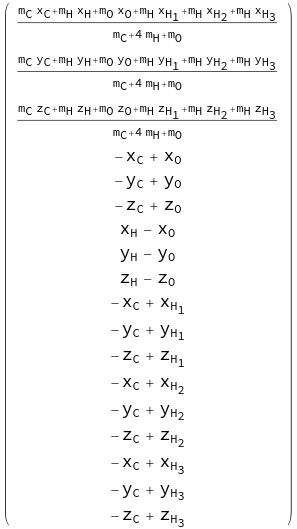
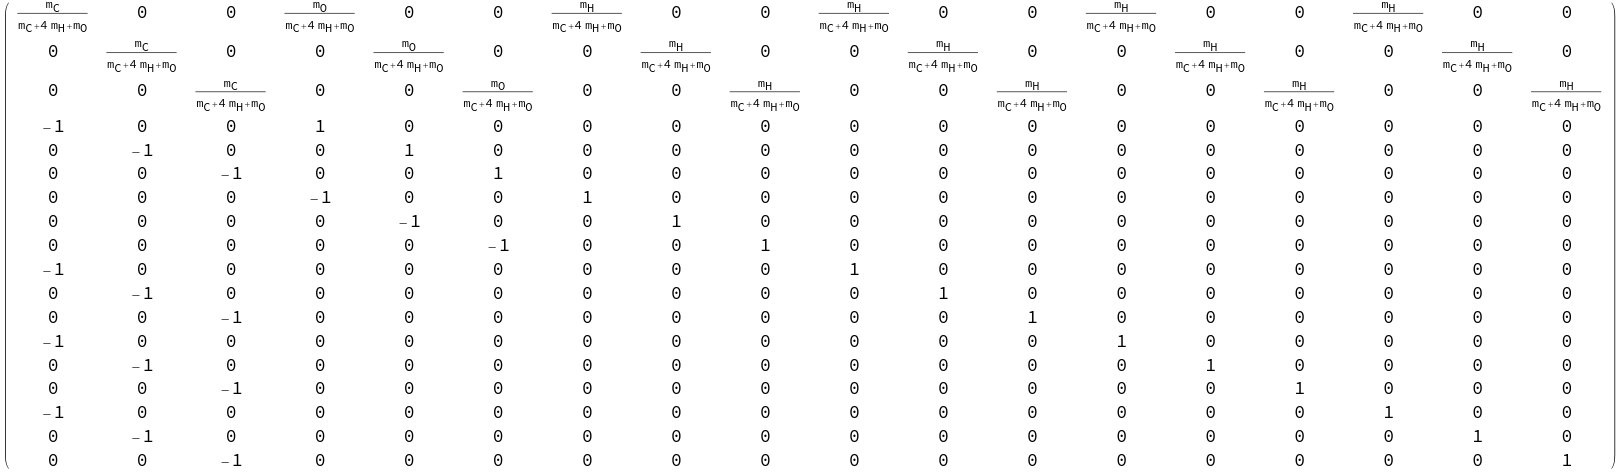

In [99]:
valenceFlattened = Flatten[valenceVectors];
MatrixForm[valenceFlattened]
sMatrixValence = ConstantArray[0, {3*numberOfAtoms, 3*numberOfAtoms}];
For[\[Lambda] = 1, \[Lambda] <= 3*numberOfAtoms, \[Lambda]++,
	For[i = 1, i <= numberOfAtoms, i++,
		For[F = 1, F <= 3, F++,
			sMatrixValence[[\[Lambda], F + (i-1)*3]] = D[valenceFlattened[[\[Lambda]]], rxyz[[i, F]]];
		];
	];
];
MatrixForm[sMatrixValence]

1    1                          1                           1
-- + --                       -(--)                         --
m    m                          m                           m
 C    O   0         0            O      0         0          C        0
 
               1                             1
               --                            --
               m                             m
>    0          C        0         0          C        0         0

          1    1                          1                           1
          -- + --                       -(--)                         --
          m    m                          m                           m
0          C    O   0         0            O      0         0          C
 
                         1                             1
                         --                            --
                         m                             m
>    0         0          C        0         0          C        0

                    1    1                          1
                    -- + --                       -(--)
                    m    m                          m
0         0          C    O   0         0            O      0         0
 
     1                             1                             1
     --                            --                            --
     m                             m                             m
>     C        0         0          C        0         0          C

  1                           1    1
-(--)                         -- + --
  m                           m    m
   O      0         0          H    O   0         0         0         0
 



>    0         0         0         0         0         0         0

            1                           1    1
          -(--)                         -- + --
            m                           m    m
0            O      0         0          H    O   0         0         0
 



>    0         0         0         0         0         0         0

                      1                           1    1
                    -(--)                         -- + --
                      m                           m    m
0         0            O      0         0          H    O   0         0
 



>    0         0         0         0         0         0         0

1                                                           1    1
--                                                          -- + --
m                                                           m    m
 C        0         0         0         0         0          C    H   0
 
               1                             1
               --                            --
               m                             m
>    0          C        0         0          C        0         0

          1                                                           1    1
          --                                                          -- + --
          m                                                           m    m
0          C        0         0         0         0         0          C    H
 
                         1                             1
                         --                            --
                         m                             m
>    0         0          C        0         0          C        0

                    1
                    --
                    m
0         0          C        0         0         0         0         0
 
     1    1                        1                             1
     -- + --                       --                            --
     m    m                        m                             m
>     C    H   0         0          C        0         0          C

1                                                           1
--                                                          --
m                                                   
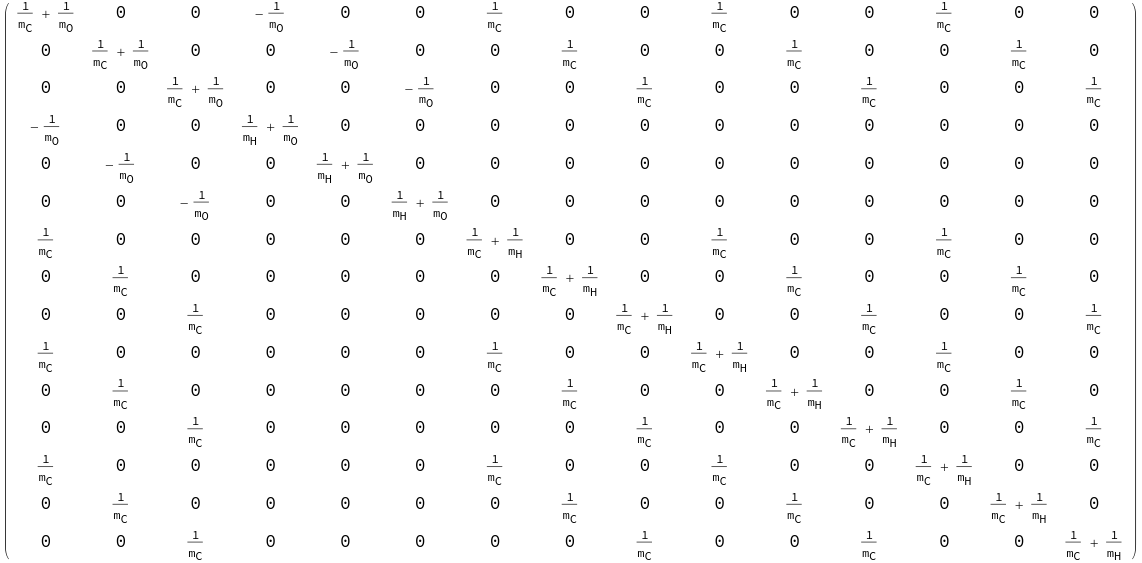

In [107]:
GMatrixValence = ConstantArray[0, {3*numberOfAtoms, 3*numberOfAtoms}];
For[\[Lambda] = 1, \[Lambda] <= 3*numberOfAtoms, \[Lambda]++,
	For[\[Nu] = 1, \[Nu] <= 3*numberOfAtoms, \[Nu]++,
		For[i = 1, i <= numberOfAtoms, i++,
			For[F = 1, F <= 3, F++,
				GMatrixValence[[\[Lambda], \[Nu]]] += (sMatrixValence[[\[Lambda], F + (i-1)*3]]*sMatrixValence[[\[Nu], F + (i-1)*3]])/masses[[i]];
			];
		];
	];
];
GMatrixValence = GMatrixValence // FullSimplify;
GMatrixValence = GMatrixValence[[4 ;;, 4 ;;]];
MatrixForm[GMatrixValence]

Sin[α   ]
     HOC


Sin[α    ]
     HCO
        1


Sin[α    ]
     HCO
        2


Sin[α    ]
     HCO
        3

        Sqrt[2] S
                 b
Sin[τ + ----------]
            3

               S          S
    Pi          a          b
Sin[-- + τ - ------- - ---------]
    6        Sqrt[6]   3 Sqrt[2]

               S          S
    Pi          a          b
Sin[-- - τ - ------- + ---------]
    6        Sqrt[6]   3 Sqrt[2]



Cos[α   ]
     HOC


Cos[α    ]
     HCO
        1


Cos[α    ]
     HCO
        2


Cos[α    ]
     HCO
        3

        Sqrt[2] S
                 b
Cos[τ + ----------]
            3

               S          S
    Pi          a          b
Cos[-- + τ - ------- - ---------]
    6        Sqrt[6]   3 Sqrt[2]

               S          S
    Pi          a          b
Cos[-- - τ - ------- + ---------]
    6        Sqrt[6]   3 Sqrt[2]



Csc[α   ]
     HOC


Csc[α    ]
     HCO
        1


Csc[α    ]
     HCO
        2


Csc[α    ]
     HCO
        3

        Sqrt[2] S
                 b
Csc[τ + ----------]
            3

               S          S
    Pi          a          b
Csc[-- + τ - ------- - ---------]
    6        Sqrt[6]   3 Sqrt[2]

               S          S
    Pi          a          b
Csc[-- - τ - ------- + ---------]
    6        Sqrt[6]   3 Sqrt[2]



Sec[α   ]
     HOC


Sec[α    ]
     HCO
        1


Sec[α    ]
     HCO
        2


Sec[α    ]
     HCO
        3

        Sqrt[2] S
                 b
Sec[τ + ----------]
            3

               S          S
    Pi          a          b
Sec[-- + τ - ------- - ---------]
    6        Sqrt[6]   3 Sqrt[2]

               S          S
    Pi          a          b
Sec[-- - τ - ------- + ---------]
    6        Sqrt[6]   3 Sqrt[2]



Cot[α   ]
     HOC


Cot[α    ]
     HCO
        1


Cot[α    ]
     HCO
        2


Cot[α    ]
     HCO
        3

        Sqrt[2] S
                 b
Cot[τ + ----------]
            3

               S          S
    Pi          a          b
Cot[-- + τ - ------- - ---------]
    6        Sqrt[6]   3 Sqrt[2]

               S          S
    Pi          a          b
Cot[-- - τ - ------- + ---------]
    6        Sqrt[6]   3 Sqrt[2]



Tan[α   ]
     HOC


Tan[α    ]
     HCO
        1


Tan[α    ]
     HCO
        2


Tan[α    ]
     HCO
        3

        Sqrt[2] S
                 b
Tan[τ + ----------]
            3

               S          S
    Pi          a          b
Tan[-- + τ - ------- - ---------]
    6        Sqrt[6]   3 Sqrt[2]

               S          S
    Pi          a          b
Tan[-- - τ - ------- + ---------]
    6        Sqrt[6]   3 Sqrt[2]


α
 HOC


α
 HCO
    1


α
 HCO
    2


α
 HCO
    3

    Sqrt[2] S
             b
τ + ----------
        3

           S          S
Pi          a          b
-- + τ - ------- - ---------
6        Sqrt[6]   3 Sqrt[2]

           S          S
Pi          a          b
-- - τ - ------- + ---------
6        Sqrt[6]   3 Sqrt[2]
{r   > 0, r   > 0, r    > 0, r    > 0, r    > 0, Sin[α   ] > 0, Sin[α    ] > 0, 
  CO       OH       CH        CH        CH            HOC            HCO
                      1         2         3                             1
 
                                            Sqrt[2] S
                                                     b
>   Sin[α    ] > 0, Sin[α    ] > 0, Sin[τ + ----------] > 0, 
         HCO             HCO                    3
            2               3
 
                   S          S                           S          S
        Pi          a          b               Pi          a          b
>   Sin[-- + τ - ------- - ---------] > 0, Sin[-- - τ - ------- + ---------] > 0, 
        6        Sqrt[6]   3 Sqrt[2]           6        Sqrt[6]   3 Sqrt[2]
 
>   Cos[α   ] > 0, Cos[α    ] > 0, Cos[α    ] > 0, Cos[α    ] > 0, 
         HOC            HCO             HCO             HCO
                           1               2               3
 
            Sqrt[2] S                       S          S
   
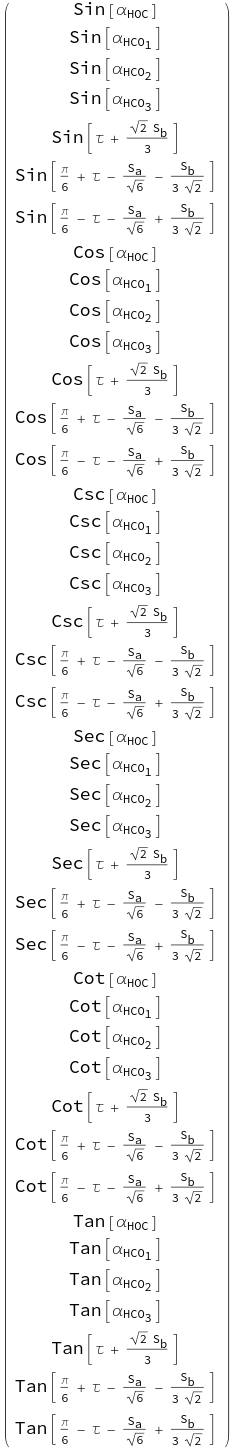
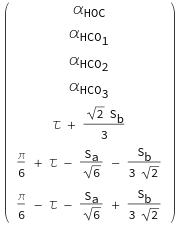
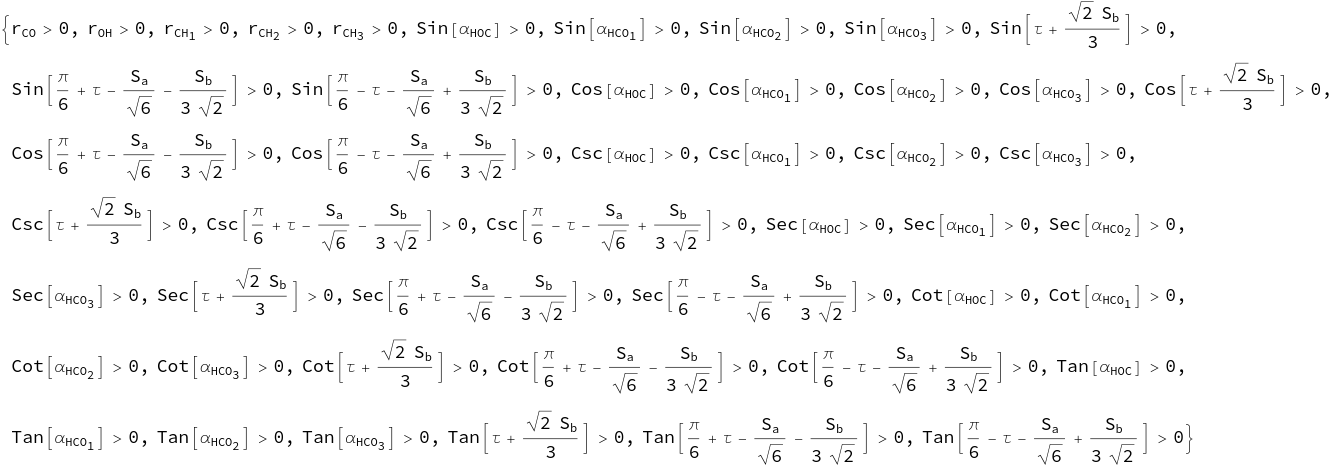
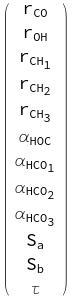

In [114]:
bondLengthAssumptions = Thread[valenceCoordinates[[1 ;; 5]] > 0];
(*(Sqrt[2] Subscript[S, b])/3, \[Pi]/6-Subscript[S, a]/Sqrt[6]+(5 Subscript[S, b])/(3 Sqrt[2]), \[Pi]/6-Subscript[S, a]/Sqrt[6]-(5 Subscript[S, b])/(3 Sqrt[2]), \[Pi]/6-\[Tau]*)
angles = Join[valenceCoordinates[[6 ;; 9]], {\[Tau]+(Sqrt[2] Subscript[S, b])/3, \[Pi]/6+\[Tau]-Subscript[S, a]/Sqrt[6]-Subscript[S, b]/(3 Sqrt[2]), \[Pi]/6-\[Tau]-Subscript[S, a]/Sqrt[6]+Subscript[S, b]/(3 Sqrt[2])}];  (* OH frame *) (*1/6 (7 \[Pi]-6 \[Tau]+2 Sqrt[2] Subscript[S, b]), \[Tau]-Subscript[S, a]/Sqrt[6]+Subscript[S, b]/(3 Sqrt[2]), 1/6 (\[Pi]+6 \[Tau]+Sqrt[6] Subscript[S, a]+Sqrt[2] Subscript[S, b]) \[Tau]+Sqrt[2/3] Subscript[S, a], \[Tau]-Subscript[S, a]/Sqrt[6]+Subscript[S, b]/Sqrt[2], \[Tau]-Subscript[S, a]/Sqrt[6]-Subscript[S, b]/Sqrt[2], \[Pi]/6-\[Tau]+(Sqrt[2] Subscript[S, b])/3, \[Tau]-Subscript[S, a]/Sqrt[6]+Subscript[S, b]/(3 Sqrt[2]), \[Tau]+1/6 (4 \[Pi]+Sqrt[6] Subscript[S, a]+Sqrt[2] Subscript[S, b]), \[Tau]-(2 \[Pi])/3, (2 \[Pi])/3-Subscript[S, a]/Sqrt[6]+(5 Subscript[S, b])/(3 Sqrt[2]), (2 \[Pi])/3-Subscript[S, a]/Sqrt[6]-(5 Subscript[S, b])/(3 Sqrt[2]), *)
(* angles = Join[valenceCoordinates[[6 ;; 9]], {\[Pi]/6-\[Tau], (Sqrt[2] Subscript[S, b])/3, \[Pi]/6-Subscript[S, a]/Sqrt[6]+(5 Subscript[S, b])/(3 Sqrt[2]), \[Pi]/6-Subscript[S, a]/Sqrt[6]-(5 Subscript[S, b])/(3 Sqrt[2])}]; *)(* Special rotated CH1 frame*)
(* angles = Join[valenceCoordinates[[6 ;; 9]], {\[Tau]+(Sqrt[2] Subscript[S, b])/3, \[Pi]/6-Subscript[S, a]/Sqrt[6]-Subscript[S, b]/Sqrt[2], \[Pi]/6-Subscript[S, a]/Sqrt[6]+Subscript[S, b]/Sqrt[2]}] *) (* CH1 frame*)
trigonometricAngles = trigAssumptions = Flatten[Map[Thread[(#[Map[# &, 
angles]])]&,
 {Sin,Cos, Csc, Sec, Cot, Tan}]];
MatrixForm[trigonometricAngles]
MatrixForm[angles]
trigAssumptions = Flatten[Map[Thread[(#[Map[# &, 
angles]] > Table[0, Length[angles]])]&,
 {Sin,Cos, Csc, Sec, Cot, Tan}]];
 trigAssumptions;
 allAssumptions = Join[bondLengthAssumptions, trigAssumptions]
 allAssumptions = bondLengthAssumptions;
 (* Mz1 = {{Cos[\[Phi]], -Sin[\[Phi]], 0}, {Sin[\[Phi]], Cos[\[Phi]], 0}, {0, 0, 1}};
 My = {{Cos[\[Theta]], 0, Sin[\[Theta]]}, {0, 1, 0},{-Sin[\[Theta]], 0, Cos[\[Theta]]}};
 Mz2 = {{Cos[\[Chi]], -Sin[\[Chi]], 0}, {Sin[\[Chi]], Cos[\[Chi]], 0}, {0, 0, 1}};
 MatrixForm[Mz1]
 MatrixForm[My]
 MatrixForm[Mz1]
 M = Mz1.My.Mz2; *)
 internalCoordinates = {Subscript[r, CO],  Subscript[r, OH], Subscript[r, Subscript[CH, 1]], Subscript[r, Subscript[CH, 2]], Subscript[r, Subscript[CH, 3]], Subscript[\[Alpha], HOC], Subscript[\[Alpha], Subscript[HCO, 1]], Subscript[\[Alpha], Subscript[HCO, 2]], Subscript[\[Alpha], Subscript[HCO, 3]], Subscript[S, a], Subscript[S, b], \[Tau]};
 MatrixForm[internalCoordinates];
 MatrixForm[valenceCoordinates]

r   > 0
 CO


r   > 0
 OH

r    > 0
 CH
   1

r    > 0
 CH
   2

r    > 0
 CH
   3
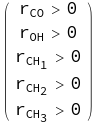

In [124]:
MatrixForm[allAssumptions]

0
 




>    0
 



     r
>     CO




Sin[α   ] r
     HOC   OH
 




>    0
 



     -(Cos[α   ] r  )
>           HOC   OH

        Sqrt[2] S
                 b
Cos[τ - ----------] Sin[α    ] r
            3            HCO    CH
                            1     1
 
             Sqrt[2] S
                      b
     Sin[τ - ----------] Sin[α    ] r
                 3            HCO    CH
>                                1     1
 


     Cos[α    ] r
          HCO    CH
>            1     1

                 S          S
      Pi          a          b
-(Sin[-- - τ - ------- - ---------] Sin[α    ] r   )
      6        Sqrt[6]   3 Sqrt[2]       HCO    CH
                                            2     2
 
                      S          S
           Pi          a          b
     -(Cos[-- - τ - ------- - ---------] Sin[α    ] r   )
           6        Sqrt[6]   3 Sqrt[2]       HCO    CH
>                                                2     2
 


     Cos[α    ] r
          HCO    CH
>            2     2

                 S          S
      Pi          a          b
-(Sin[-- + τ - ------- + ---------] Sin[α    ] r   )
      6        Sqrt[6]   3 Sqrt[2]       HCO    CH
                                            3     3
 
                    S          S
         Pi          a          b
     Cos[-- + τ - ------- + ---------] Sin[α    ] r
         6        Sqrt[6]   3 Sqrt[2]       HCO    CH
>                                              3     3
 


     Cos[α    ] r
          HCO    CH
>            3     3






0
 





     r
>     CO
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0






-r
  CO
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0







0
 






>    0
 






>    0
 






>    1
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0







0
 





     -(Cos[α   ] r  )
>           HOC   OH
 






>    0
 






>    0
 





     Sin[α   ]
>         HOC
 






>    0
 






>    0
 






>    0
 





     Cos[α   ] r
>         HOC   OH
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0






Cos[α   ] r
     HOC   OH
 






>    0
 





     Sin[α   ] r
>         HOC   OH
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0







0
 





     -(Sin[α   ] r  )
>           HOC   OH
 






>    0
 






>    0
 





     -Cos[α   ]
>          HOC
 






>    0
 






>    0
 






>    0
 





     Sin[α   ] r
>         HOC   OH
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0
 






>    0







0
 




     Cos[α    ] r
          HCO    CH
>            1     1
 


               Sqrt[2] S
                        b
     -(Sin[τ - ----------] Sin[α    ] r   )
                   3            HCO    CH
>                                  1     1
 






>    0
 






>    0
 


             Sqrt[2] S
                      b
     Cos[τ - ----------] Sin[α    ]
                 3            HCO
>                                1
 






>    0
 






>    0
 






>    0
 


             Sqrt[2] S
                      b
     Cos[τ - ----------] Cos[α    ] r
                 3            HCO    CH
>                                1     1
 






>    0
 






>    0
 






>    0
 
                     Sqrt[2] S
                              b
     Sqrt[2] Sin[τ - ----------] Sin[α    ] r
                         3            HCO    CH
                                         1     1
     
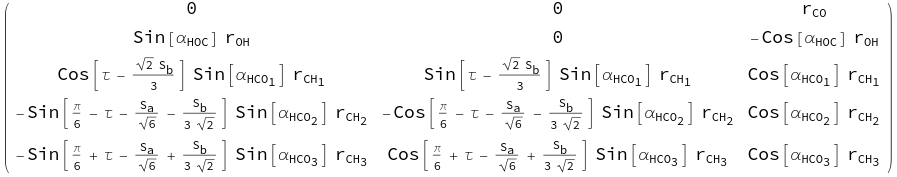
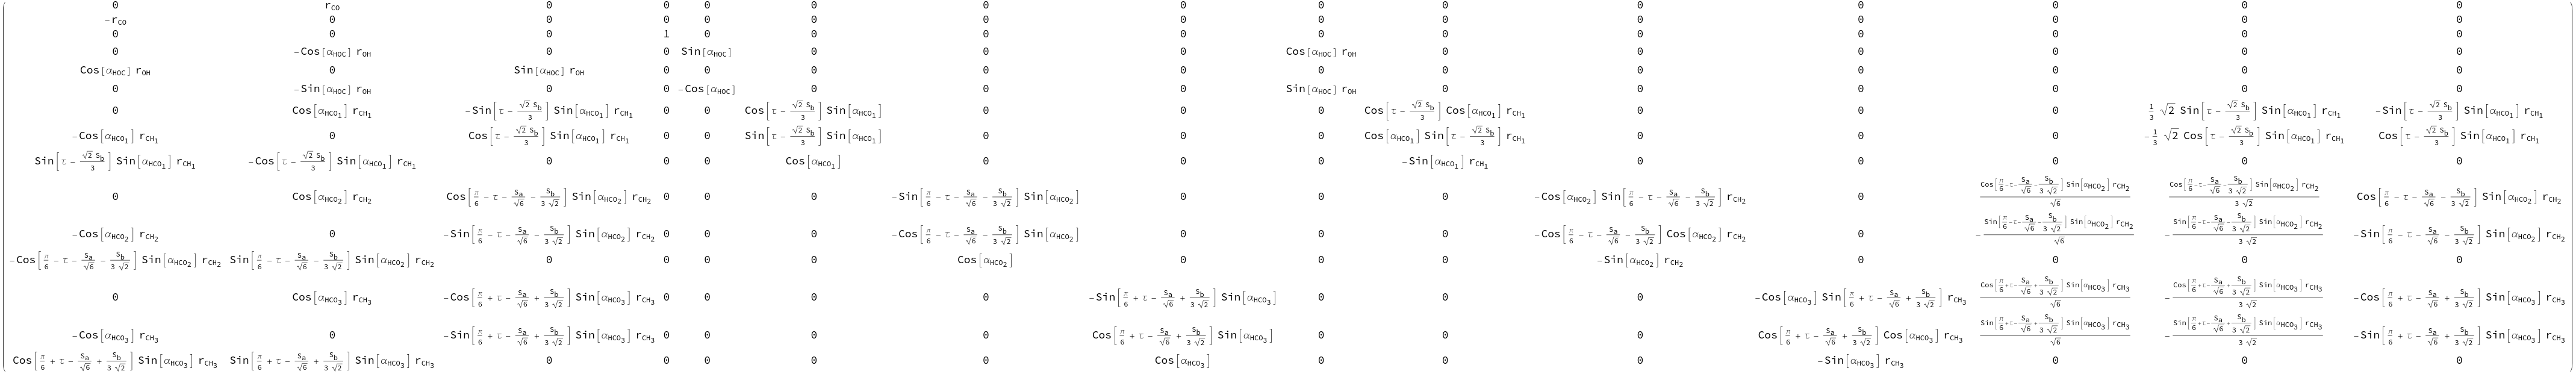

In [136]:
numberOfInternalCoordinates = 3*numberOfAtoms - 3;
(* Frame rotated by sqrt(2)Sb/3 *)
(* valenceInInternalCoordinates = {{0, 0, Subscript[r, CO]},
{Subscript[r, OH]*Sin[Subscript[\[Alpha], HOC]]*Cos[\[Tau]-(2 \[Pi])/3], -Subscript[r, OH]*Sin[Subscript[\[Alpha], HOC]]*Sin[\[Tau]-(2 \[Pi])/3], -Subscript[r, OH]*Cos[Subscript[\[Alpha], HOC]]},
{Subscript[r, Subscript[CH, 1]]*Sin[Subscript[\[Alpha], Subscript[HCO, 1]]]*Cos[(Sqrt[2] Subscript[S, b])/3], Subscript[r, Subscript[CH, 1]]*Sin[(Sqrt[2] Subscript[S, b])/3]*Sin[Subscript[\[Alpha], Subscript[HCO, 1]]], Subscript[r, Subscript[CH, 1]]*Cos[Subscript[\[Alpha], Subscript[HCO, 1]]]},
{Subscript[r, Subscript[CH, 2]]*Cos[(2 \[Pi])/3-Subscript[S, a]/Sqrt[6]+(5 Subscript[S, b])/(3 Sqrt[2])]*Sin[Subscript[\[Alpha], Subscript[HCO, 2]]], Subscript[r, Subscript[CH, 2]]*Sin[(2 \[Pi])/3-Subscript[S, a]/Sqrt[6]+(5 Subscript[S, b])/(3 Sqrt[2])]*Sin[Subscript[\[Alpha], Subscript[HCO, 2]]], Subscript[r, Subscript[CH, 2]]*Cos[Subscript[\[Alpha], Subscript[HCO, 2]]]},
{Subscript[r, Subscript[CH, 3]]*Cos[(2 \[Pi])/3-Subscript[S, a]/Sqrt[6]-(5 Subscript[S, b])/(3 Sqrt[2])]*Sin[Subscript[\[Alpha], Subscript[HCO, 3]]], -Subscript[r, Subscript[CH, 3]]*Sin[(2 \[Pi])/3-Subscript[S, a]/Sqrt[6]-(5 Subscript[S, b])/(3 Sqrt[2])]*Sin[Subscript[\[Alpha], Subscript[HCO, 3]]], Subscript[r, Subscript[CH, 3]]*Cos[Subscript[\[Alpha], Subscript[HCO, 3]]]}}; *)
(* CH1 frame *)
(* valenceInInternalCoordinates = {{0, 0, Subscript[r, CO]},
{Subscript[r, OH]*Sin[Subscript[\[Alpha], HOC]]*Cos[\[Tau]+(Sqrt[2] Subscript[S, b])/3], Subscript[r, OH]*Sin[Subscript[\[Alpha], HOC]]*Sin[\[Tau]+(Sqrt[2] Subscript[S, b])/3], -Subscript[r, OH]*Cos[Subscript[\[Alpha], HOC]]},
{Subscript[r, Subscript[CH, 1]]*Sin[Subscript[\[Alpha], Subscript[HCO, 1]]], 0, Subscript[r, Subscript[CH, 1]]*Cos[Subscript[\[Alpha], Subscript[HCO, 1]]]},
{Subscript[r, Subscript[CH, 2]]*Cos[(2 \[Pi])/3-Subscript[S, a]/Sqrt[6]-Subscript[S, b]/Sqrt[2]]*Sin[Subscript[\[Alpha], Subscript[HCO, 2]]], Subscript[r, Subscript[CH, 2]]*Sin[(2 \[Pi])/3-Subscript[S, a]/Sqrt[6]-Subscript[S, b]/Sqrt[2]]*Sin[Subscript[\[Alpha], Subscript[HCO, 2]]], Subscript[r, Subscript[CH, 2]]*Cos[Subscript[\[Alpha], Subscript[HCO, 2]]]},
{Subscript[r, Subscript[CH, 3]]*Cos[(2 \[Pi])/3-Subscript[S, a]/Sqrt[6]+Subscript[S, b]/Sqrt[2]]*Sin[Subscript[\[Alpha], Subscript[HCO, 3]]], -Subscript[r, Subscript[CH, 3]]*Sin[(2 \[Pi])/3-Subscript[S, a]/Sqrt[6]+Subscript[S, b]/Sqrt[2]]*Sin[Subscript[\[Alpha], Subscript[HCO, 3]]], Subscript[r, Subscript[CH, 3]]*Cos[Subscript[\[Alpha], Subscript[HCO, 3]]]}}; *)
(* OH frame dihedral differences *)
(* valenceInInternalCoordinates = {{0, 0, Subscript[r, CO]},
{Subscript[r, OH]*Sin[Subscript[\[Alpha], HOC]], 0, - Subscript[r, OH]*Cos[Subscript[\[Alpha], HOC]]},
{Subscript[r, Subscript[CH, 1]]*Cos[\[Tau]+(Sqrt[2] Subscript[S, b])/3]*Sin[Subscript[\[Alpha], Subscript[HCO, 1]]], Subscript[r, Subscript[CH, 1]]*Sin[\[Tau]+(Sqrt[2] Subscript[S, b])/3]*Sin[Subscript[\[Alpha], Subscript[HCO, 1]]], Subscript[r, Subscript[CH, 1]]*Cos[Subscript[\[Alpha], Subscript[HCO, 1]]]},
{Subscript[r, Subscript[CH, 2]]*Cos[(2 \[Pi])/3+\[Tau]-Subscript[S, a]/Sqrt[6]-Subscript[S, b]/(3 Sqrt[2])]*Sin[Subscript[\[Alpha], Subscript[HCO, 2]]], Subscript[r, Subscript[CH, 2]]*Sin[(2 \[Pi])/3+\[Tau]-Subscript[S, a]/Sqrt[6]-Subscript[S, b]/(3 Sqrt[2])]*Sin[Subscript[\[Alpha], Subscript[HCO, 2]]], Subscript[r, Subscript[CH, 2]]*Cos[Subscript[\[Alpha], Subscript[HCO, 2]]]},
{Subscript[r, Subscript[CH, 3]]*Cos[(4 \[Pi])/3+\[Tau]+Subscript[S, a]/Sqrt[6]-Subscript[S, b]/(3 Sqrt[2])]*Sin[Subscript[\[Alpha], Subscript[HCO, 3]]], Subscript[r, Subscript[CH, 3]]*Sin[(4 \[Pi])/3+\[Tau]+Subscript[S, a]/Sqrt[6]-Subscript[S, b]/(3 Sqrt[2])]*Sin[Subscript[\[Alpha], Subscript[HCO, 3]]], Subscript[r, Subscript[CH, 3]]*Cos[Subscript[\[Alpha], Subscript[HCO, 3]]]}}; *)
(* OH frame dihedral differences swap 2 and 3 *)
 valenceInInternalCoordinates = {{0, 0, Subscript[r, CO]},
{Subscript[r, OH]*Sin[Subscript[\[Alpha], HOC]], 0, - Subscript[r, OH]*Cos[Subscript[\[Alpha], HOC]]},
{Subscript[r, Subscript[CH, 1]]*Cos[\[Tau]-(Sqrt[2] Subscript[S, b])/3]*Sin[Subscript[\[Alpha], Subscript[HCO, 1]]], Subscript[r, Subscript[CH, 1]]*Sin[\[Tau]-(Sqrt[2] Subscript[S, b])/3]*Sin[Subscript[\[Alpha], Subscript[HCO, 1]]], Subscript[r, Subscript[CH, 1]]*Cos[Subscript[\[Alpha], Subscript[HCO, 1]]]},
{Subscript[r, Subscript[CH, 2]]*Cos[(4 \[Pi])/3+\[Tau]+Subscript[S, a]/Sqrt[6]+Subscript[S, b]/(3 Sqrt[2])]*Sin[Subscript[\[Alpha], Subscript[HCO, 2]]], Subscript[r, Subscript[CH, 2]]*Sin[(4 \[Pi])/3+\[Tau]+Subscript[S, a]/Sqrt[6]+Subscript[S, b]/(3 Sqrt[2])]*Sin[Subscript[\[Alpha], Subscript[HCO, 2]]], Subscript[r, Subscript[CH, 2]]*Cos[Subscript[\[Alpha], Subscript[HCO, 2]]]},
{Subscript[r, Subscript[CH, 3]]*Cos[(2 \[Pi])/3+\[Tau]-Subscript[S, a]/Sqrt[6]+Subscript[S, b]/(3 Sqrt[2])]*Sin[Subscript[\[Alpha], Subscript[HCO, 3]]], Subscript[r, Subscript[CH, 3]]*Sin[(2 \[Pi])/3+\[Tau]-Subscript[S, a]/Sqrt[6]+Subscript[S, b]/(3 Sqrt[2])]*Sin[Subscript[\[Alpha], Subscript[HCO, 3]]], Subscript[r, Subscript[CH, 3]]*Cos[Subscript[\[Alpha], Subscript[HCO, 3]]]}};  
(* OH frame torsional dihedrals *)
(* valenceInInternalCoordinates = {{0, 0, Subscript[r, CO]},
{Subscript[r, OH]*Sin[Subscript[\[Alpha], HOC]], 0, - Subscript[r, OH]*Cos[Subscript[\[Alpha], HOC]]},
{Subscript[r, Subscript[CH, 1]]*Cos[(2 \[Pi])/3+\[Tau]+Sqrt[2/3] Subscript[S, a]]*Sin[Subscript[\[Alpha], Subscript[HCO, 1]]], Subscript[r, Subscript[CH, 1]]*Sin[(2 \[Pi])/3+\[Tau]+Sqrt[2/3] Subscript[S, a]]*Sin[Subscript[\[Alpha], Subscript[HCO, 1]]], Subscript[r, Subscript[CH, 1]]*Cos[Subscript[\[Alpha], Subscript[HCO, 1]]]},
{Subscript[r, Subscript[CH, 2]]*Cos[(2 \[Pi])/3+\[Tau]-Subscript[S, a]/Sqrt[6]+Subscript[S, b]/Sqrt[2]]*Sin[Subscript[\[Alpha], Subscript[HCO, 2]]], Subscript[r, Subscript[CH, 2]]*Sin[(2 \[Pi])/3+\[Tau]-Subscript[S, a]/Sqrt[6]+Subscript[S, b]/Sqrt[2]]*Sin[Subscript[\[Alpha], Subscript[HCO, 2]]], Subscript[r, Subscript[CH, 2]]*Cos[Subscript[\[Alpha], Subscript[HCO, 2]]]},
{Subscript[r, Subscript[CH, 3]]*Cos[(2 \[Pi])/3+\[Tau]-Subscript[S, a]/Sqrt[6]-Subscript[S, b]/Sqrt[2]]*Sin[Subscript[\[Alpha], Subscript[HCO, 3]]], Subscript[r, Subscript[CH, 3]]*Sin[(2 \[Pi])/3+\[Tau]-Subscript[S, a]/Sqrt[6]-Subscript[S, b]/Sqrt[2]]*Sin[Subscript[\[Alpha], Subscript[HCO, 3]]], Subscript[r, Subscript[CH, 3]]*Cos[Subscript[\[Alpha], Subscript[HCO, 3]]]}}; *)
MatrixForm[valenceInInternalCoordinates]
tMatrix = ConstantArray[0, {numberOfInternalCoordinates, numberOfInternalCoordinates}];
For[i = 1, i <= numberOfAtoms - 1, i++,
	For[F = 1, F <= 3, F++,
		For[\[Lambda] = 4, \[Lambda] <= numberOfInternalCoordinates, \[Lambda]++,
			tMatrix[[F + (i-1)*3, \[Lambda]]] = D[valenceInInternalCoordinates[[i, F]], internalCoordinates[[\[Lambda] - 3]]];
		];
	];
];
For[i = 1, i <= numberOfAtoms - 1, i++,
	For[F = 1, F <= 3, F++,
		For[\[Lambda] = 1, \[Lambda] <= 3, \[Lambda]++,
			tMatrix[[F + (i-1)*3, \[Lambda]]] = (LeviCivitaTensor[3] . valenceInInternalCoordinates[[i, ;;]])[[F, \[Lambda]]];
		];
	];
];
MatrixForm[tMatrix]

0      1     0   0   0   0   0   0   0   0   0   0   0   0   0
    -(---)
      r
       CO

 1    0   0   0   0   0   0   0   0   0   0   0   0   0   0
---
r
 CO

0   Cot[α   ] / r     0   0   Csc[α   ] / r     0   0   0   0   0   0   0   0   0   0
         HOC     CO                HOC     OH

0   0   1   0   0   0   0   0   0   0   0   0   0   0   0

0   0   0   Sin[α   ]   0   -Cos[α   ]   0   0   0   0   0   0   0   0   0
                 HOC              HOC

0   0   0   0   0   0   Cos[τ - (Sqrt[2] S ) / 3] Sin[α    ]   Sin[τ - (Sqrt[2] S ) / 3] 
                                          b            HCO                       b
                                                          1     
                                                               >   Sin[α    ]
                                                                        HCO
                                                                           1
 
>       Cos[α    ]   0   0   0   0   0   0
             HCO
                1

0   0   0   0   0   0   0   0   0         Pi
                                    -(Sin[-- - τ - S  / Sqrt[6] - S  / (3 Sqrt[2])] 
                                          6         a              b
                                     
                                    >     Sin[α    ])
                                               HCO
                                                  2
 
>             Pi                                                      Cos[α    ]   0
        -(Cos[-- - τ - S  / Sqrt[6] - S  / (3 Sqrt[2])] Sin[α    ])        HCO
              6         a              b                     HCO              2
                                                                2
 
>       0   0

0   0   0   0   0   0   0   0   0   0   0   0         Pi
                                                -(Sin[-- + τ - S  / Sqrt[6] + 
                                                      6         a
                                                 
                                                >       S  / (3 Sqrt[2])] Sin[α    ])
                                                         b                     HCO
                                                                                  3
 
>           Pi                                                     Cos[α    ]
        Cos[-- + τ - S  / Sqrt[6] + S  / (3 Sqrt[2])] Sin[α    ]        HCO
            6         a              b                     HCO             3
                                                              3

 1    0   0   Cos[α   ] / r     0   Sin[α   ] / r     0   0   0   0   0   0   0   0
---                HOC     OH            HOC     OH
r
 CO
 
>       0

-(Cos[τ - (Sqrt[2] S ) / 3] / r  )                2
                    b          CO    -((Cos[α    ]  Sin[τ - (Sqrt[2] S ) / 3]) / r  ) - 
                                             HCO                      b           CO
                                                1
                                      
                                                                   2
                                     >   (Cos[τ - (Sqrt[2] S ) / 3]  
                                                            b
                                      
                                                                                2
                                     >      Sin[τ - (Sqrt[2] S ) / 3] Sin[α    ] ) / r  \
                                                              b            HCO        CO
                                                                              1
                                      
                                                                      3           2
                                     >    - (Sin[τ - (Sqrt[2] S ) / 3]  Sin[α    ] ) / 
                                                               b             HCO
                                                                                1
                             
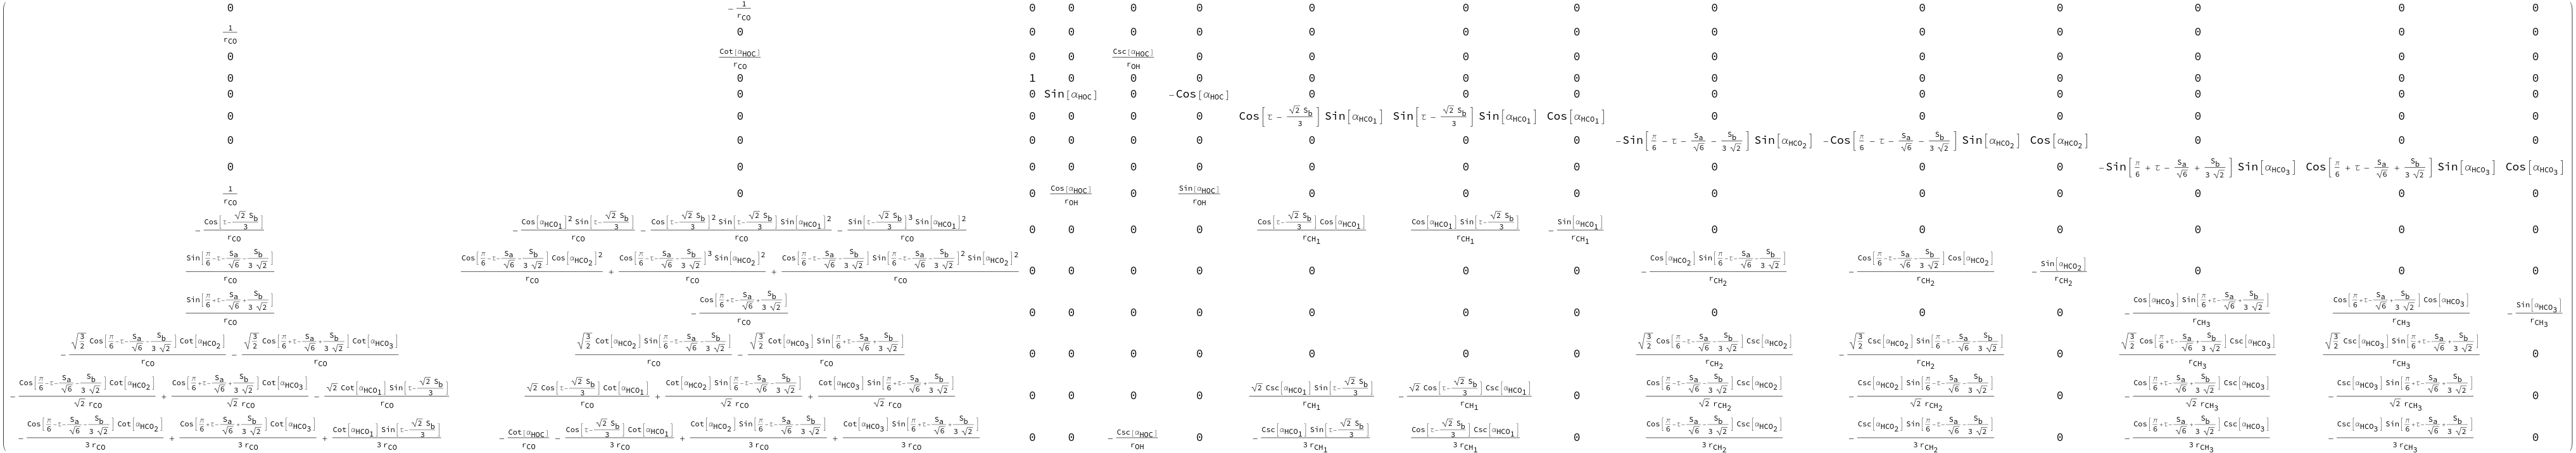

In [144]:
sMatrix = Inverse[tMatrix];
sMatrix = FullSimplify[sMatrix // Factor, allAssumptions, Trig->False,TransformationFunctions->{(#//.Sin[a_]^2+Cos[a_]^2:>1)&,(#//. 1-Cos[a_]^2:>Sin[a]^2)&,(#//. 1-Sin[a_]^2:>Cos[a]^2)&,(#//. 1+Cot[a_]^2:>Csc[a]^2)&,(# //. 1+Tan[a_]^2 :> Sec[a]^2&),(#//.b_*Sin[a_]^2+b_*Cos[a_]^2:>b)& }] // Expand;
sMatrix = FullSimplify[sMatrix, allAssumptions, Trig->False, TransformationFunctions->{(#//. Power[Times[e_,b_],f_]:> Times[Power[e,f],Power[b,f]]&),(#//.Power[Power[e_,2],Rational[1,2]]:> e &),(# //. Power[Power[e_,2],Rational[-1,2]]:> Power[e,-1] &)}];
MatrixForm[sMatrix]

2               2    0                        2                        2
1 / (m  r   ) + 1 / (m  r   )       -(Cot[α   ] / (m  r   )) - Cot[α   ] / (m  r   ) + 
      C  CO           O  CO                HOC      C  CO           HOC      O  CO
                                     
                                    >   Csc[α   ] / (m  r   r  )
                                             HOC      O  CO  OH
 
>       0   0   -((Cos[(Sqrt[2] S ) / 3] Sin[τ] Sin[α    ]) / (m  r  )) +    (Sqrt[3] 
                                 b                   HCO        C  CO         
                                                        1                    >      Cos[
                                                                              
                >   (Cos[τ] Sin[(Sqrt[2] S ) / 3] Sin[α    ]) / (m  r  )     >      τ] 
                                          b            HCO        C  CO       
                                                          1                  >      Cos[
                                                                              
                                                                             >      S  / 
                                                                                     a
                                                                              
                                                                             >      Sqrt[
                                                                              
                                                                             >      6]] 
                                                                              
                                                                             >      Cos[
                                                                              
                                                                             >      S  / 
                                                                                     b
                                                                              
                                                                             >      
                                                                              
                                                                             >    (3 
                                                                              
                                                                             >      Sqrt[
                                                                              
                                                                             >      2])] 
                                                                              
                                                                             >      Sin[
                                                                              
                                                                             >      α
                                                                              
                                                                             >         ])
                                                                                   HCO
                                                                                      2
                                                                              
                                                                             >      / 
                                                                              
                                                                             >     (2 m  
                                                                                       C
                                                                              
                                                                             >      r  )\
                                           
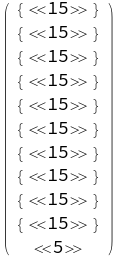

In [148]:
GMatrix = ConstantArray[0, {numberOfInternalCoordinates, numberOfInternalCoordinates}];
For[\[Lambda] = 1, \[Lambda] <= numberOfInternalCoordinates, \[Lambda]++,
	For[\[Nu] = 1, \[Nu] <= numberOfInternalCoordinates, \[Nu]++,
		For[i = 1, i <= numberOfAtoms - 1, i++,
			For[j = 1, j <= numberOfAtoms - 1, j++,
				For[F = 1, F <= 3, F++,
					GMatrix[[\[Lambda], \[Nu]]] += GMatrixValence[[F + (i - 1)*3, F + (j - 1)*3]]*sMatrix[[\[Lambda], F + (i - 1)*3]]*sMatrix[[\[Nu], F + (j - 1)*3]];
				];
			];
		];
	];
];
GMatrix = FullSimplify[GMatrix // Factor, allAssumptions, Trig->False,TransformationFunctions->{(#//.Sin[a_]^2+Cos[a_]^2:>1)&,(#//. 1-Cos[a_]^2:>Sin[a]^2)&,(#//. 1-Sin[a_]^2:>Cos[a]^2)&,(#//. 1+Cot[a_]^2:>Csc[a]^2)&,(# //. 1+Tan[a_]^2 :> Sec[a]^2&),(#//.b_*Sin[a_]^2+b_*Cos[a_]^2:>b)& }] // Expand // TrigExpand;
MatrixForm[GMatrix]

In [149]:
(GMatrix[[13, 15]] /. massSubstitution) /. coordinateEquilibriumSubstitution
(GMatrix[[14, 15]] /. massSubstitution) /. coordinateEquilibriumSubstitution
(GMatrix[[15, 15]] /. massSubstitution) /. coordinateEquilibriumSubstitution

-33        -34
0. 10    + 0. 10    Cos[τ] + 0.096178575153408512238349183583557 Sin[τ]
     -33                                                     -34
0. 10    - 0.096178575153408512238349183583557 Cos[τ] + 0. 10    Sin[τ]
                                           -34               -34
1.631980671778724270173863579778306 + 0. 10    Cos[τ] + 0. 10    Sin[τ]